# Ridge Regression

# Theory

## Bias and Variance

---

* **Bias** represents the deviation from the original data and predicted values by the model.
* More bias represents more deviations and hence the model failed to fit the data properly.
* Bias is the result of an inconsistent model being used on the data.

> **Note:** To reduce or eliminate bias, we may have to change the model. We have to use an appropriate model that perfectly fits the data.

---

When we use the correct model to fit the given data but it fails on future data, it is known as **Variance**.

* The model works well on train data, but it fails when used on new data (or test data).
    * When the model works well on train data, it represents **low bias**.
    * But when it fails on new data, it represents **high variance**.

> **Note:** So, bias and variance are inversely proportional to each other. This is the **bias-variance trade-off**.

---

### Underfitting and Overfitting

> If the model shows **high bias and low variance**, it is called ***underfitting***. On the other hand, if the model shows **low bias and high variance**, then it is called ***overfitting***.

## Regularization

---

* Regularization is a technique to minimize variance or overfitting, making it possible to achieve better model accuracy.
* When regularization is used in a Linear Regression model, it gives rise to variations such as:
    1. Ridge Regression
    2. Lasso Regression
    3. ElasticNET Regression
* To control the impact on bias and variance, a regularization parameter by the $\lambda$ is used.
---
### **How Alpha ($\alpha$) Controls the Model** (Penalty Parameter)

The parameter **$\alpha$ (alpha)** acts like a dial that controls how heavily we penalize large coefficients in Ridge Regression. 

*   **When $\alpha = 0$:**
    *   **What happens:** The penalty is completely turned off. The model works exactly like regular Linear Regression.
    *   **The Tradeoff:** **Low Bias, High Variance** (The model fits the training data perfectly but is prone to **overfitting**).

*   **As $\alpha$ increases (goes toward infinity):**
    *   **What happens:** The penalty gets stronger, forcing the model's coefficients closer and closer to zero.
    *   **The Tradeoff:** **High Bias, Low Variance** (The model becomes simpler and less sensitive to noise, but if $\alpha$ is too high, it will **underfit**).

> **In short:** 
> * **Raise $\alpha$** to fix overfitting (lowers variance).
> * **Lower $\alpha$** to fix underfitting (lowers bias).

# Program 1: 
> *We have weight and height and of somne people in 2 separate .csv files. Use train.csv and test.csv files to retrieve training and testing data. Fit Simple Linear Regression on training data and Ridge Regression on testing data. Also, predict height of a person having 70.3 kg weight.*

### Data given: train.csv, test.csv

In [23]:
import pandas as pd

# Load train and test datasets
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [24]:
# Extract features and targets
X_train = w_train = train_df[['Weight']].values
y_train = h_train = train_df['Height'].values

X_test = w_test = test_df[['Weight']].values
y_test = h_test = test_df['Height'].values

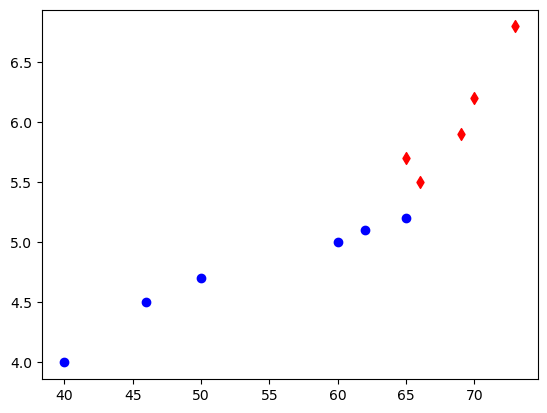

In [25]:
# draw a scatter plot for train and test data in the same graph
import matplotlib.pyplot as plt 
plt.scatter(w_train , h_train , color = 'blue', marker='o')
plt.scatter(w_test, h_test, color= 'red', marker= 'd')
plt.show()

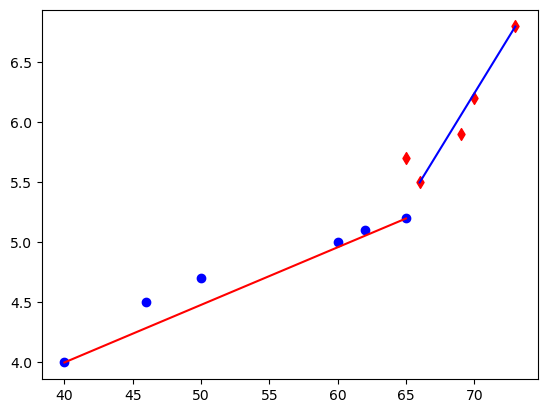

In [26]:
# draw a scatter plot for train and test data in the same graph
import matplotlib.pyplot as plt 
plt.scatter(w_train , h_train , color = 'blue', marker='o')
plt.scatter(w_test, h_test, color= 'red', marker= 'd')

# Line 1: Connects first point to last point of train data
plt.plot([w_train[0], w_train[-1]], [h_train[0], h_train[-1]], color='r')

# Line 2: Connects first point to last point of test data
plt.plot([w_test[0], w_test[-1]], [h_test[0], h_test[-1]], color='b')
plt.show()

In [27]:
# using Simple Linear Regression o fit train data 
from sklearn.linear_model import LinearRegression , Ridge

In [28]:
lr = LinearRegression()
lr.fit(w_train, h_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
#find the score of the simple Linear Regression on train data
# R² score on the training data
train_score = lr.score(w_train, h_train)
print(f"Simple Linear Regression Train Score: {train_score}")

Simple Linear Regression Train Score: 0.9554154968329801


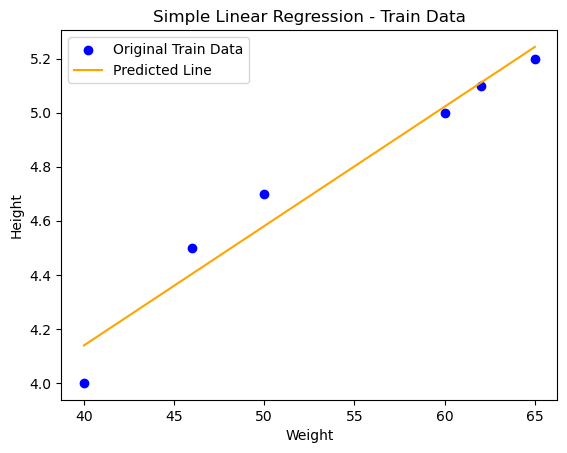

In [30]:
# Draw scatter plot with original training data and predicted line
plt.scatter(w_train, h_train, color='blue', label='Original Train Data')
plt.plot(w_train, lr.predict(w_train), color='orange', label='Predicted Line')
plt.title('Simple Linear Regression - Train Data')
plt.xlabel('Weight')
plt.ylabel('Height')
plt.legend()
plt.show()

In [31]:
# using Ridge Regressi on to fit a line for test data
# take alpha values as: 0.001, 0.01, 0.05, 0.5, 1, 2, etc

# List of alpha values to evaluate
alpha_values = [0.001, 0.01, 0.05, 0.5, 1, 2]

print("\n--- Ridge Regression Scores on Test Data ---")
for alpha in alpha_values:
    rr = Ridge(alpha=alpha)
    rr.fit(w_test, h_test)
    test_score = rr.score(w_test, h_test)*100
    print(f"Alpha: {alpha:<5} -> Test R^2 Score: {test_score:.6f}%")


--- Ridge Regression Scores on Test Data ---
Alpha: 0.001 -> Test R^2 Score: 89.011560%
Alpha: 0.01  -> Test R^2 Score: 89.011555%
Alpha: 0.05  -> Test R^2 Score: 89.011429%
Alpha: 0.5   -> Test R^2 Score: 88.998763%
Alpha: 1     -> Test R^2 Score: 88.961577%
Alpha: 2     -> Test R^2 Score: 88.820777%


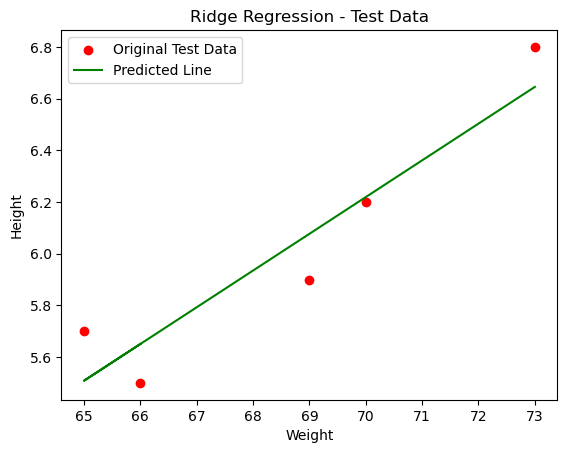

In [32]:
# Draw scatter plot with original data and predicted line
plt.scatter(w_test, h_test, color='red', label='Original Test Data')
plt.plot(w_test, rr.predict(w_test), color='green', label='Predicted Line')
plt.title('Ridge Regression - Test Data')
plt.xlabel('Weight')
plt.ylabel('Height')
plt.legend()
plt.show()

In [33]:
# Predict height for 70.3 kg weight using the trained Ridge model
import numpy as np
weight_to_predict = np.array([[70.3]])
predicted_height = rr.predict(weight_to_predict)

print(f"Predicted Height for 70.3 kg: {predicted_height[0]:.2f}")

Predicted Height for 70.3 kg: 6.26


# Program 2:
### Dataset given: boston_houses.csv
<details>
<summary><b>Click to expand: Boston Housing Dataset Column Descriptions</b></summary>

| Column Name | Description |
| :--- | :--- |
| **CRIM** | Per capita crime rate by town |
| **ZN** | Proportion of residential land zoned for lots over 25,000 sq.ft. |
| **INDUS** | Proportion of non-retail business acres per town |
| **CHAS** | Charles River dummy variable ($1$ if tract bounds river; $0$ otherwise) |
| **NOX** | Nitric oxides concentration (parts per 10 million) |
| **RM** | Average number of rooms per dwelling |
| **AGE** | Proportion of owner-occupied units built prior to 1940 |
| **DIS** | Weighted distances to five Boston employment centres |
| **RAD** | Index of accessibility to radial highways |
| **TAX** | Full-value property-tax rate per $\$10,000$ |
| **PTRATIO** | Pupil-teacher ratio by town |
| **B** | $1000(Bk - 0.63)^2$ where $Bk$ is the proportion of blacks by town |
| **LSTAT** | % lower status of the population |
| **Price** | Median value of owner-occupied homes in $\$1000$'s |

</details>

In [34]:
import pandas as pd 
df = pd.read_csv('boston_houses.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
0,0.0063,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.0273,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.0273,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.0324,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.0690,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,3.33,36.2


In [35]:
x = df[['RM']].values
y = df.iloc[:,-1].values

In [36]:
from sklearn.model_selection import train_test_split
x_train, x_test , y_train, y_test = train_test_split(x , y, test_size=.2, random_state=1)

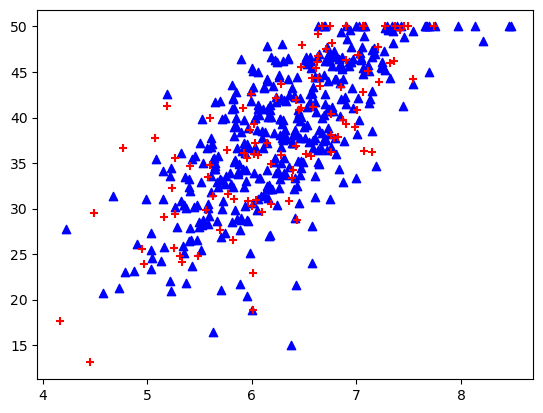

In [37]:
# draw scatter plot for train and test data in the same graph 
import matplotlib.pyplot as plt 
plt.scatter(x_train, y_train , color = 'blue', marker='^')
plt.scatter(x_test, y_test, color = 'red', marker = '+')
plt.show()

In [38]:
# using linear regression fit a line for the train data 
from sklearn.linear_model import LinearRegression
lr = LinearRegression() 
lr.fit(x_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [39]:
lr.score(x_train, y_train)

0.5053716856746258

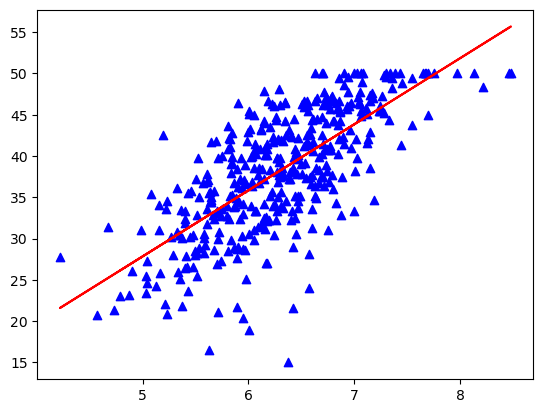

In [40]:
# display the train data with regression 1ine
plt.scatter (x_train, y_train, color='blue', marker='^')
plt.plot (x_train, lr.predict(x_train), color='red')
plt.show()

In [41]:
# using Ridge regression to fit a line for test data
# take alpha values as: 0.001, 0.01, 0.05, 0.5, 1, 2, et

from sklearn.linear_model import Ridge
rr = Ridge()
# List of alpha values to evaluate
alpha_values = [0.001, 0.01, 0.05, 0.5, 1, 2]

print("\n--- Ridge Regression Scores on Test Data ---")
for alpha in alpha_values:
    rr = Ridge(alpha=alpha)
    rr.fit(x_test, y_test)
    test_score = rr.score(x_test, y_test)*100
    print(f"Alpha: {alpha:<5} -> Test R^2 Score: {test_score:.6f}%")


--- Ridge Regression Scores on Test Data ---
Alpha: 0.001 -> Test R^2 Score: 57.743674%
Alpha: 0.01  -> Test R^2 Score: 57.743672%
Alpha: 0.05  -> Test R^2 Score: 57.743630%
Alpha: 0.5   -> Test R^2 Score: 57.739394%
Alpha: 1     -> Test R^2 Score: 57.726845%
Alpha: 2     -> Test R^2 Score: 57.678600%


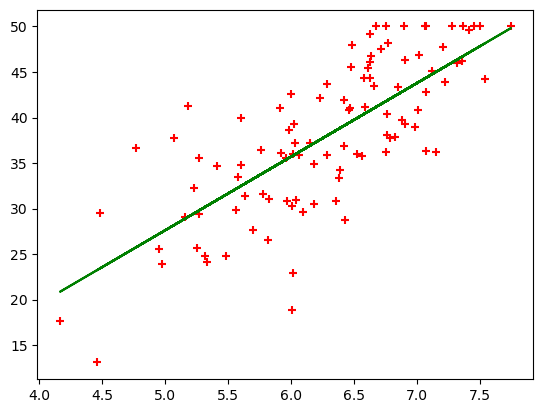

In [42]:
# display the test data with regression line
plt.scatter(x_test, y_test, color='red', marker='+')
plt.plot (x_test ,rr.predict(x_test), color='green')
plt.show()

In [43]:
# predict price of a house having 6.5 rooms
rr.predict([[6.5]]) 

array([39.75935923])

# -- Ends Here --